In [166]:
import numpy as np
from math import pi, sin, cos, pi, sqrt
import matplotlib.pyplot as plt

accel_des_store = []
point_store = []
diff_store = []

def velocity_controller(current_vel, vel_des):
    k_accel = -0.6
    dot_prod = vel_des[0]*current_vel[0]*cos(vel_des[1]-current_vel[1])
    accel_des = k_accel * (current_vel[0]**2 - dot_prod) + -0.05 * (current_vel[0] - vel_des[0])*cos(vel_des[1]-current_vel[1])

    k_omega = 0.5
    required_turn = vel_des[1]-current_vel[1]
    required_turn = (required_turn + np.pi) % (2 * np.pi) - np.pi

    alpha = 5
    omega_des = k_omega * required_turn
    1 + alpha * current_vel[0]

    max_omega = 1 /  (1 + alpha * (current_vel[0]))
    max_accel = 0.3*9.8
    omega_des = np.clip(omega_des, -max_omega, max_omega)
    accel_des = np.clip(accel_des, -max_accel, max_accel)

    return accel_des, omega_des


In [167]:

for theta in np.linspace(0, 2*pi, 40):
    for mag in np.linspace(0, 1, 20):
        current_vel = np.array([0.5, 0])
        vel_des = np.array([mag, theta])

        accel_des, diff = velocity_controller(current_vel, vel_des)

        accel_des_store.append(accel_des)
        diff_store.append(diff)
        point_store.append(np.array([mag, theta]))

def polar_diff_mag(v1, v2):
    # v1, v2 = [r, theta]
    x1, y1 = v1[0] * np.cos(v1[1]), v1[0] * np.sin(v1[1])
    x2, y2 = v2[0] * np.cos(v2[1]), v2[0] * np.sin(v2[1])
    return np.linalg.norm([x2 - x1, y2 - y1])

In [168]:
all_paths = []

target_headings = np.linspace(0, 2*pi, 9)

for theta_des in target_headings:
    # theta_des = pi
    current_position = np.array([0,0])
    current_vel = np.array([1, 0])
    vel_des = np.array([1, theta_des])

    current_path = []

    for _ in range(500):  # safety limit
        accel_des, diff = velocity_controller(current_vel, vel_des)
        current_vel = current_vel + 0.05 * np.array([accel_des, diff])
        current_vel[1] = (current_vel[1] + np.pi) % (2 * np.pi) - np.pi

        dx = current_vel[0] * cos(current_vel[1])
        dy = current_vel[0] * sin(current_vel[1])
        current_position = current_position + np.array([dx, dy])

        current_path.append(current_position.copy())

        if polar_diff_mag(current_vel, vel_des) < 0.05:
            print("Target Heading Reached! Number of iterations: ", _)
            break
        elif _ == 499:
            print("Failed. Heading is ", current_vel, " target was ", vel_des)

    all_paths.append(np.array(current_path))


Target Heading Reached! Number of iterations:  0
Target Heading Reached! Number of iterations:  126
Target Heading Reached! Number of iterations:  185
Target Heading Reached! Number of iterations:  212
Target Heading Reached! Number of iterations:  239
Target Heading Reached! Number of iterations:  212
Target Heading Reached! Number of iterations:  185
Target Heading Reached! Number of iterations:  126
Target Heading Reached! Number of iterations:  0


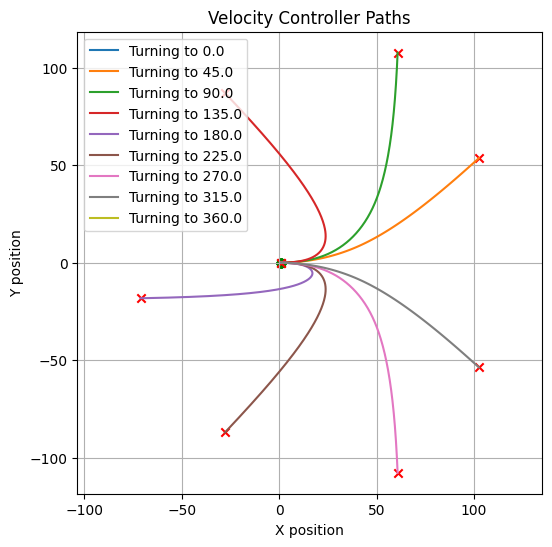

In [169]:
plt.figure(figsize=(6, 6))
for i, path in enumerate(all_paths):
    plt.plot(path[:, 0], path[:, 1], label=f'Turning to {target_headings[i]*180/pi}')
    plt.scatter(path[0, 0], path[0, 1], c='green', marker='o')  # start
    plt.scatter(path[-1, 0], path[-1, 1], c='red', marker='x')  # end

plt.title('Velocity Controller Paths')
plt.xlabel('X position')
plt.ylabel('Y position')
plt.axis('equal')
plt.legend()
plt.grid(True)
plt.show()

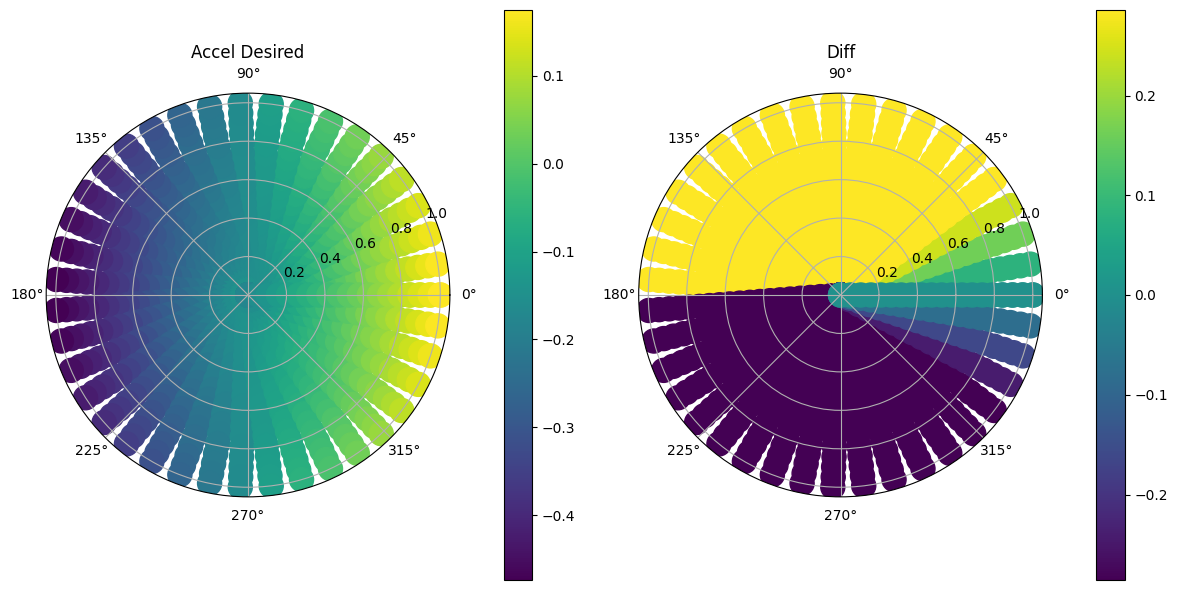

In [170]:
import numpy as np
import matplotlib.pyplot as plt

# Convert lists to arrays
points = np.array(point_store)  # shape (N, 2)
mag = points[:, 0]
theta = points[:, 1]

accel_des = np.array(accel_des_store)
diff = np.array(diff_store)

# Create two polar subplots side by side
fig, axes = plt.subplots(1, 2, subplot_kw={'projection': 'polar'}, figsize=(12, 6))
titles = ['Accel Desired', 'Diff']
data_list = [accel_des, diff]

for ax, data, title in zip(axes, data_list, titles):
    sc = ax.scatter(theta, mag, c=data, cmap='viridis', s=300)
    ax.set_title(title)
    fig.colorbar(sc, ax=ax, pad=0.1)
    ax.grid(True)

plt.tight_layout()
plt.show()
